# Exploring Text Data
### Table of Contents
1. About the Dataset
2. Generating Word Frequency
3. EDA using Word Clouds
4. Text Cleaning

## 1. About the Dataset

In [1]:
import pandas as pd

#Load the dataset
df = pd.read_csv('tweets.csv', encoding = 'ISO-8859-1')

In [2]:
# Printing shape of dataframe
print('Shape=>',df.shape)

Shape=> (14940, 16)


In [3]:
df.head()

,Unnamed: 0,X,text,favorited,favoriteCount,replyToSN,created,truncated,replyToSID,id,replyToUID,statusSource,screenName,retweetCount,isRetweet,retweeted
0,1,1,RT @rssurjewala: Critical question: Was PayTM ...,False,0,NaN,2016-11-23 18:40:30,False,NaN,8.014957e+17,NaN,"<a href=""http://twitter.com/download/android"" ...",HASHTAGFARZIWAL,331,True,False
1,2,2,RT @Hemant_80: Did you vote on #Demonetization...,False,0,NaN,2016-11-23 18:40:29,False,NaN,8.014957e+17,NaN,"<a href=""http://twitter.com/download/android"" ...",PRAMODKAUSHIK9,66,True,False
2,3,3,"RT @roshankar: Former FinSec, RBI Dy Governor,...",False,0,NaN,2016-11-23 18:40:03,False,NaN,8.014955e+17,NaN,"<a href=""http://twitter.com/download/android"" ...",rahulja13034944,12,True,False
3,4,4,RT @ANI_news: Gurugram (Haryana): Post office ...,False,0,NaN,2016-11-23 18:39:59,False,NaN,8.014955e+17,NaN,"<a href=""http://twitter.com/download/android"" ...",deeptiyvd,338,True,False
4,5,5,RT @satishacharya: Reddy Wedding! @mail_today ...,False,0,NaN,2016-11-23 18:39:39,False,NaN,8.014954e+17,NaN,"<a href=""http://cpimharyana.com"" rel=""nofollow...",CPIMBadli,120,True,False


## 2. Generating Word Frequency

In [4]:
import spacy

In [5]:
# Loading model
nlp=spacy.load('en_core_web_sm')

In [6]:
# Combining tweets into a single string
combined_tweets=' '.join(df.text.values)

In [9]:
# Increasing the max_length limit
nlp.max_length = len(combined_tweets) + 1000

# Creating Doc object
doc=nlp(combined_tweets)

In [10]:
# Function for generating word frequency
def gen_freq(tokens):
    
    # Creating a pandas series with word frequencies
    word_freq = pd.Series([token.text for token in tokens]).value_counts()
    
    # Printing frequencies
    print(word_freq[:20])
    
    return word_freq

In [11]:
# Getting word frequency
word_freq=gen_freq(doc)

#                 13753
:                 13147
RT                11057
                  8816
to                 7661
demonetization     7615
.                  6211
Demonetization     5481
\r\n               5208
is                 5183
,                  4573
in                 4505
the                4342
of                 4060
's                 3041
India              2930
Modi               2828
on                 2768
PM                 2713
-                  2637
Name: count, dtype: int64


## 3. EDA using Word Clouds
**Note:-** You can install `WordCloud` library by - 

`pip install wordcloud`

In [12]:
#Importing libraries
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [13]:
# Function for generating wordcloud
def generate_wordcloud(data):
    # Creating a wordcloud
    wc = WordCloud(width=400, height=330, max_words=200,background_color='white').generate_from_frequencies(data)
    
    # Setting Figure Size
    plt.figure(figsize=(14,12))
    
    # Display wordcloud as image
    plt.imshow(wc, interpolation='bilinear')
    
    # Removing all the axes
    plt.axis("off")
    
    plt.show()

In [14]:
print('No. of unique words=>',len(word_freq))

No. of unique words=> 16141


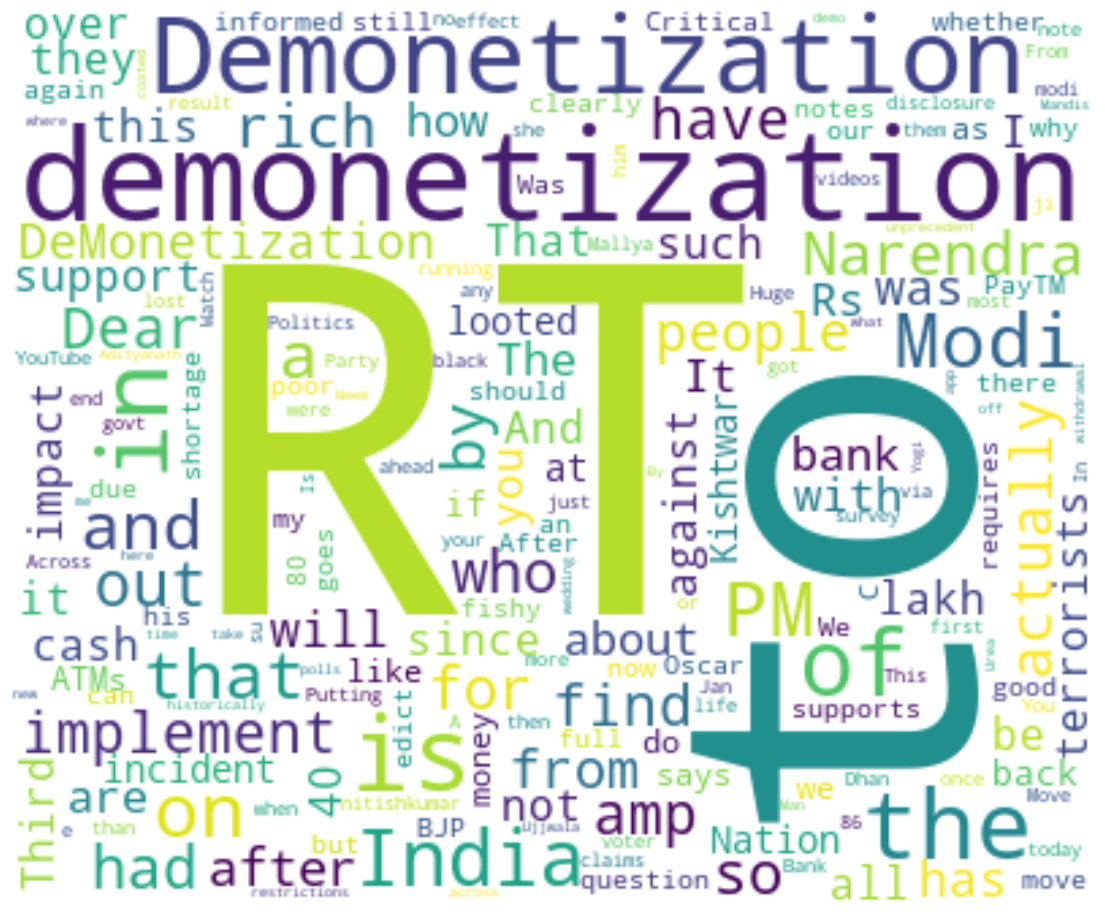

In [17]:
# Cleaning word frequencies to remove unsupported characters
cleaned_word_freq = word_freq[word_freq.index.str.match(r'^[a-zA-Z0-9]+$')]

# Generating wordcloud
generate_wordcloud(cleaned_word_freq)

## 4. Text Cleaning - Part-1

In [18]:
import re

In [19]:
# Removing RT and # from tweets
combined_tweets=re.sub('(RT|#)','',combined_tweets)

In [20]:
# Lowercasing the text
combined_tweets=combined_tweets.lower()

In [21]:
# Creating Doc object
doc=nlp(combined_tweets)

In [22]:
# Removing stopwords and punctuations
tokens=[token for token in doc if (token.is_stop==False|token.is_punct==False)]

In [23]:
# Getting word frequencies
word_freq=gen_freq(tokens)

demonetization      14457
                    6188
                     5683
\r\n                 5206
modi                 3090
india                2986
pm                   2752
                    2627
>                    1624
narendra             1566
rich                 1511
find                 1422
dear                 1411
implement            1400
actually             1374
@evanspiegel         1311
amp                  1302
<                    1287
@urautelaforever     1273
people               1215
Name: count, dtype: int64


In [24]:
print('No. of unique words=>',len(word_freq))

No. of unique words=> 13949


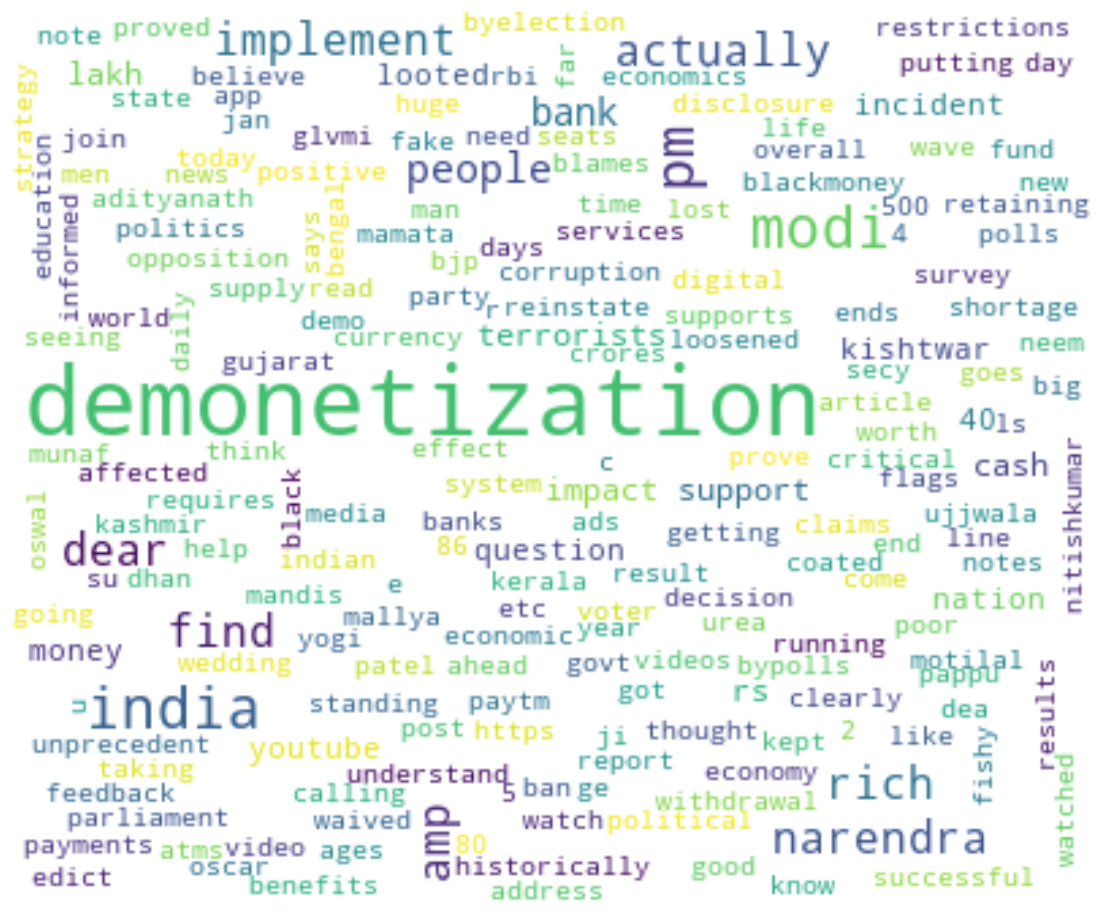

In [26]:
# Cleaning word frequencies to remove unsupported characters
cleaned_word_freq = word_freq[word_freq.index.str.match(r'^[a-zA-Z0-9]+$')]

# Generating wordcloud
generate_wordcloud(cleaned_word_freq)

## Text Cleaning - Part-2

In [27]:
# Combining tokens into a text
combined_tweets=' '.join([token.text for token in tokens])

In [28]:
# Removing "\r\n", "amp", "<", ">" from the text
combined_tweets=re.sub('(\r\n|amp|<|>)+','',combined_tweets)

In [29]:
# Creating Doc object
doc=nlp(combined_tweets)

In [30]:
# Removing whitespaces
tokens=[token for token in doc if (token.is_space==False)]

In [31]:
# Getting word frequencies
word_freq=gen_freq(tokens)

demonetization      14461
modi                 3090
india                2986
pm                   2754
narendra             1566
rich                 1511
find                 1422
dear                 1411
implement            1400
actually             1374
@evanspiegel         1311
@urautelaforever     1273
people               1215
@narendramodi        1142
bank                 1043
rs                    741
cash                  707
impact                703
lakh                  685
support               681
Name: count, dtype: int64


In [32]:
print('No. of unique words=>',len(word_freq))

No. of unique words=> 13906


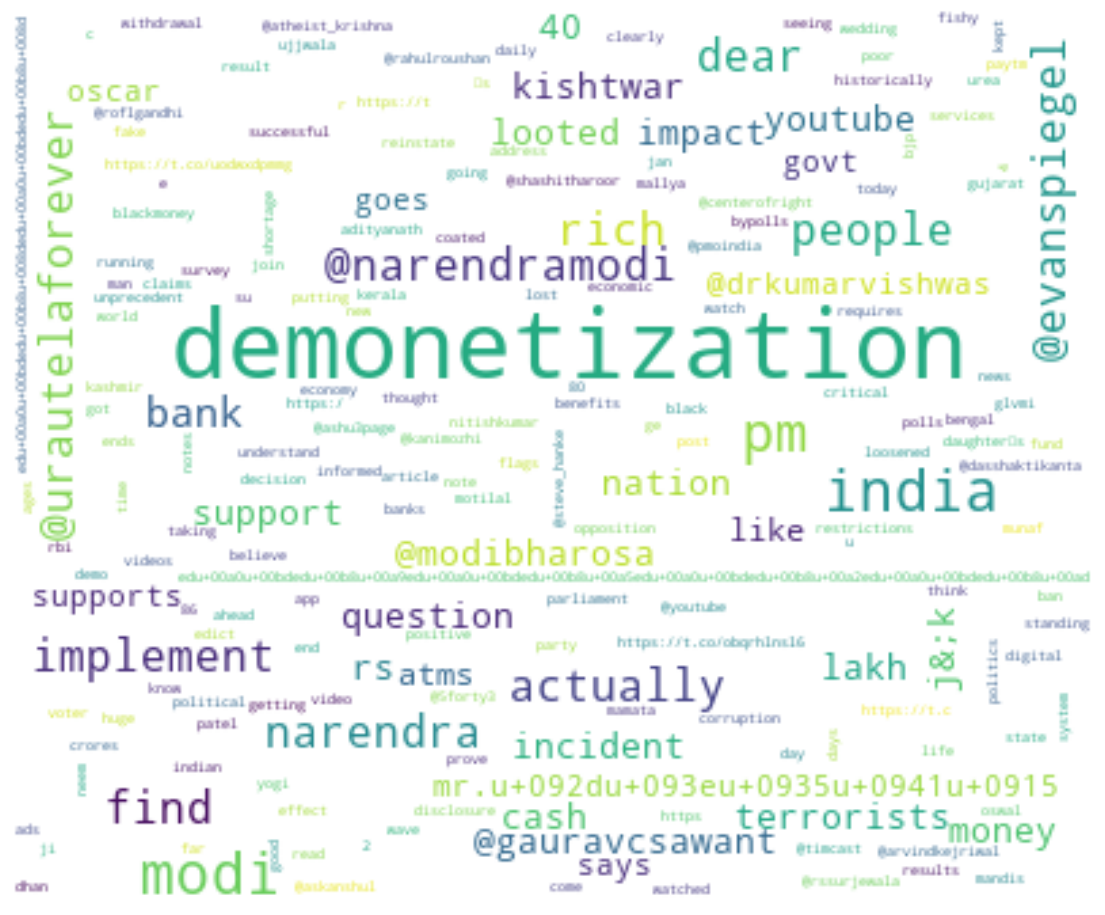

In [33]:
# Generating wordcloud
generate_wordcloud(word_freq)